# 02_ImageFiltering
## One-Dimensional Signals and Moving-Average Filtering

Before working with two-dimensional images, we will begin with a simpler object: a one-dimensional signal.

A one-dimensional signal can represent quantities such as:

- sound amplitude measured over time,
- temperature measured throughout a day,
- the intensity values along one row of an image, or
- the height of a wave sampled at different positions.

We will represent a signal using the symbol $I$.

## What does $I \in \mathbb{R}^{m \times 1}$ mean?

The notation

$$
I \in \mathbb{R}^{m \times 1}
$$

tells us what kind of mathematical object $I$ is.

- $\mathbb{R}$ means that the entries of $I$ are real numbers.
- $m$ is the number of entries in the signal.
- $m \times 1$ means that $I$ is represented mathematically as a column vector with $m$ rows and one column.

Therefore,

$$
I =
\begin{bmatrix}
I[0] \\
I[1] \\
I[2] \\
\vdots \\
I[m-1]
\end{bmatrix}.
$$

Each $I[i]$ is one sample from the signal.

We use zero-based indexing here to match Python: the first sample is $I[0]$ and the last sample is $I[m-1]$.

In [16]:
import numpy as np

# A signal containing five real-valued samples
I = np.array([1.2, 2.0, 3.5, 2.8, 4.1])

print("Signal:", I)
print("Number of samples:", len(I))
print("NumPy shape:", I.shape)

Signal: [1.2 2.  3.5 2.8 4.1]
Number of samples: 5
NumPy shape: (5,)


Although we write $I \in \mathbb{R}^{m \times 1}$ mathematically, NumPy normally represents a one-dimensional signal using shape `(m,)`.

If we specifically want a two-dimensional column vector with shape `(m, 1)`, we can reshape it.

In [3]:
I_column = I.reshape(-1, 1)

print(I_column)
print("Column-vector shape:", I_column.shape)

[[1.2]
 [2. ]
 [3.5]
 [2.8]
 [4.1]]
Column-vector shape: (5, 1)


## Understanding summation notation

Consider the expression

$$
\sum_{i=a}^{b} I[i].
$$

The symbol $\sum$ tells us to add a sequence of values. The variable $i$ is the index that changes.

The lower value, $i=a$, tells us where to begin. The upper value, $b$, tells us where to stop.

Therefore,

$$
\sum_{i=a}^{b} I[i]
=
I[a] + I[a+1] + I[a+2] + \cdots + I[b].
$$

For example,

$$
\sum_{i=1}^{3} I[i]
=
I[1] + I[2] + I[3].
$$

Unlike a Python slice, the upper endpoint of a mathematical sum is included.

In [6]:
I = np.array([10, 20, 30, 40, 50])

# Mathematical expression:
# sum from i = 1 through i = 3 of I[i]

total_with_loop = 0

for i in range(1, 4):
    total_with_loop = total_with_loop + I[i]

# Python slices exclude the ending index.
# Therefore, I[1:4] contains I[1], I[2], and I[3].
total_with_slice = np.sum(I[1:4])

print("Values being added:", I[1:4])
print("Using a loop:", total_with_loop)
print("Using np.sum:", total_with_slice)

Values being added: [20 30 40]
Using a loop: 90
Using np.sum: 90


## Moving-average filtering

Real signals frequently contain noise: unwanted variation that obscures the underlying pattern.

A moving-average filter reduces rapid fluctuations by replacing each value with the average of nearby values.

For a window containing $k$ samples, the moving average is

$$
h[n]
=
\frac{1}{k}
\sum_{i=n-k+1}^{n} I[i].
$$

Here:

- $I$ is the original signal,
- $h$ is the filtered signal,
- $n$ is the location at which we calculate the output,
- $k$ is the window size.

Expanding the summation gives

$$
h[n]
=
\frac{
I[n-k+1] + I[n-k+2] + \cdots + I[n]
}{k}.
$$

In words, we take the current sample $I[n]$ and the previous $k-1$ samples, add them, and divide by $k$.

For example, if $k=3$, then

$$
h[n]
=
\frac{I[n-2] + I[n-1] + I[n]}{3}.
$$

In [8]:
I = np.array([4.0, 7.0, 10.0, 5.0, 8.0])

k = 3
n = 3

# The mathematical window runs from n-k+1 through n.
start = n - k + 1

# Python excludes the ending index, so we use n+1.
window = I[start:n + 1]

h_n = np.sum(window) / k

print("Original signal:", I)
print("Current index n:", n)
print("Window:", window)
print("Moving average h[n]:", h_n)

Original signal: [ 4.  7. 10.  5.  8.]
Current index n: 3
Window: [ 7. 10.  5.]
Moving average h[n]: 7.333333333333333


## Creating a noisy sine wave

We will now construct a one-dimensional signal based on the sine function:

$$
I_{\text{clean}}[n] = \sin(x_n).
$$

We then add random noise:

$$
I[n] = I_{\text{clean}}[n] + \epsilon[n],
$$

where $\epsilon[n]$ represents the noise at sample $n$.

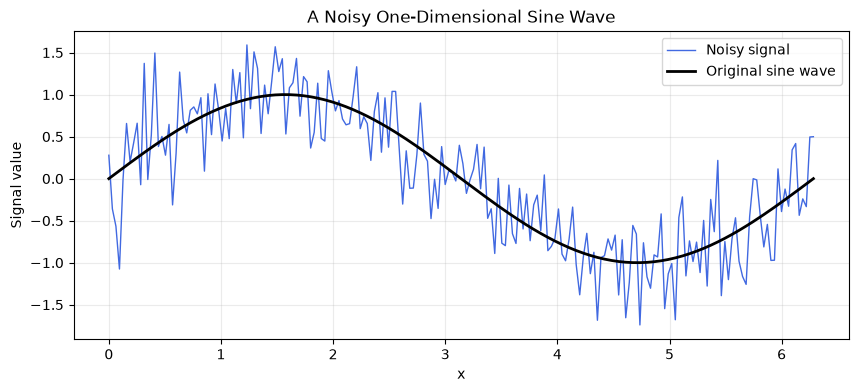

In [10]:
import matplotlib.pyplot as plt

# Use a fixed seed so the experiment is reproducible.
rng = np.random.default_rng(14)

m = 200
x = np.linspace(0, 2 * np.pi, m)

clean_signal = np.sin(x)
noise = rng.normal(loc=0.0, scale=0.40, size=m)
I = clean_signal + noise

plt.figure(figsize=(10, 4))
plt.plot(x, I, color="royalblue", linewidth=1, label="Noisy signal")
plt.plot(x, clean_signal, color="black", linewidth=2, label="Original sine wave")

plt.xlabel("x")
plt.ylabel("Signal value")
plt.title("A Noisy One-Dimensional Sine Wave")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Implementing the moving average

We will use a window size of $k=11$.

For every valid value of $n$, we calculate

$$
h[n]
=
\frac{1}{11}
\sum_{i=n-10}^{n} I[i].
$$

The first valid output occurs at $n=k-1$, because earlier positions do not have $k$ available samples.

For example, when $k=11$, the first complete window is

$$
I[0], I[1], \ldots, I[10].
$$

We will initially place `NaN` in positions where a complete window is unavailable. Matplotlib will leave those positions blank.

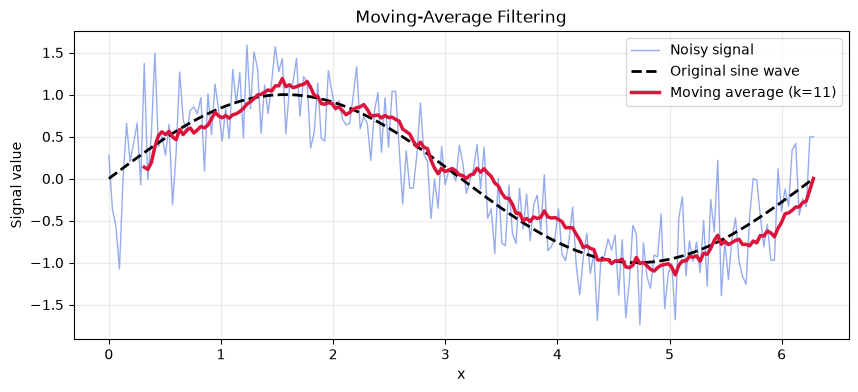

In [12]:
k = 11

# Create an output signal with the same length as I.
# NaN marks positions where a complete window is unavailable.
h = np.full(m, np.nan)

for n in range(k - 1, m):
    window = I[n - k + 1:n + 1]
    h[n] = np.sum(window) / k

plt.figure(figsize=(10, 4))
plt.plot(x, I, color="royalblue", linewidth=1,
         alpha=0.55, label="Noisy signal")
plt.plot(x, clean_signal, color="black", linewidth=2,
         linestyle="--", label="Original sine wave")
plt.plot(x, h, color="crimson", linewidth=2.5,
         label=f"Moving average (k={k})")

plt.xlabel("x")
plt.ylabel("Signal value")
plt.title("Moving-Average Filtering")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

The moving-average signal is smoother because each output combines information from several neighboring samples.

Random positive and negative fluctuations tend to cancel when averaged. As a result, the underlying sine-wave pattern becomes easier to see.

However, smoothing introduces tradeoffs:

- A larger window removes more noise.
- A larger window can also remove important signal details.
- This implementation uses the current and previous samples, so the filtered signal can appear delayed.
- The beginning of the signal cannot be calculated without deciding how to handle the boundary.

Filtering therefore requires us to decide which variations are noise and which variations contain useful information.

## NumPy's convolution implementation (Optional observation)

A moving average can also be written using a filter kernel:

$$
w =
\frac{1}{k}
\begin{bmatrix}
1 & 1 & \cdots & 1
\end{bmatrix}.
$$

Every entry in the kernel has the value $1/k$, so the kernel weights all samples in the window equally.

NumPy can apply this kernel using `np.convolve()`.

In [14]:
moving_average_kernel = np.ones(k) / k

# "valid" returns values only where the entire kernel overlaps the signal.
h_convolve = np.convolve(I, moving_average_kernel, mode="valid")

# These should equal the values produced by our loop.
h_loop_valid = h[k - 1:]

print("Kernel:", moving_average_kernel)
print("Outputs are equal:",
      np.allclose(h_convolve, h_loop_valid))

Kernel: [0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]
Outputs are equal: True


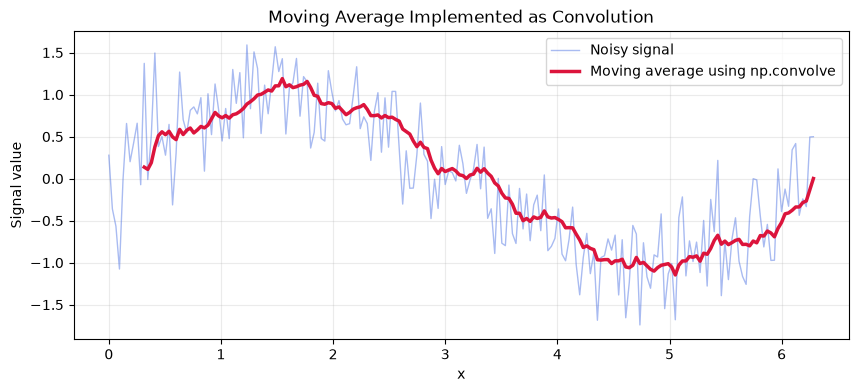

In [15]:
x_valid = x[k - 1:]

plt.figure(figsize=(10, 4))
plt.plot(x, I, color="royalblue", linewidth=1,
         alpha=0.45, label="Noisy signal")
plt.plot(x_valid, h_convolve, color="crimson", linewidth=2.5,
         label="Moving average using np.convolve")

plt.xlabel("x")
plt.ylabel("Signal value")
plt.title("Moving Average Implemented as Convolution")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Filtering Demo

Visit [this site](https://cristal.univ-lille.fr/~casiez/1euro/InteractiveDemo/) for a filtering demo. Moving the cursor up and down creates a signal. The filtered results are shown in real time below.
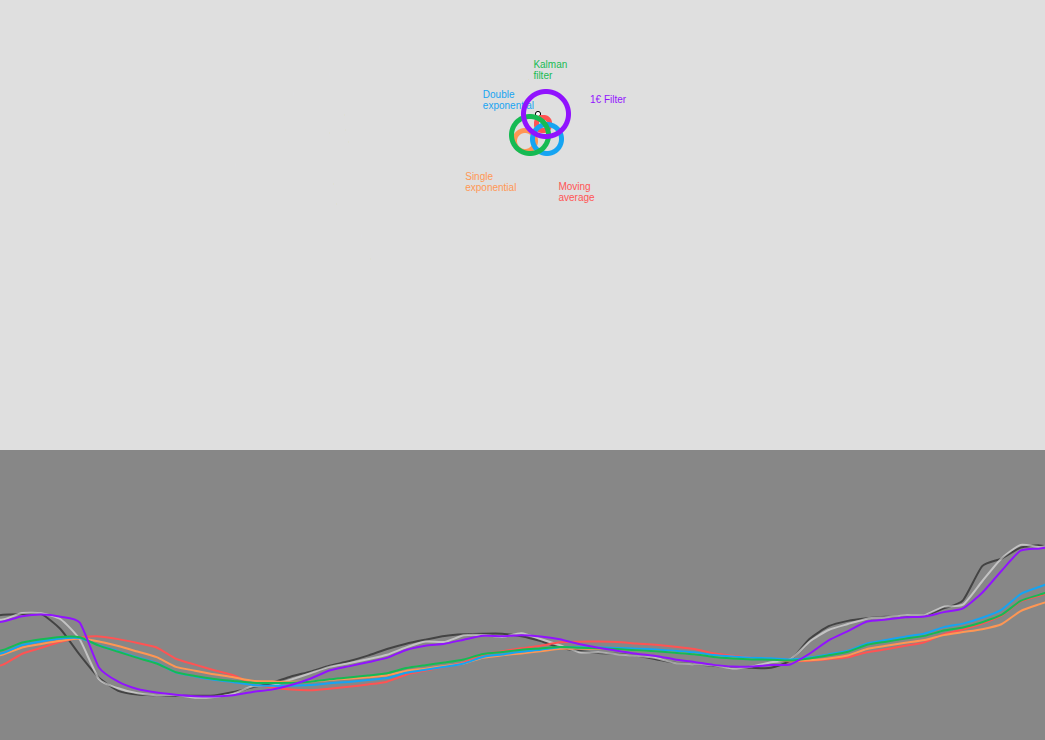

# Two-Dimensional Filtering

A grayscale image is a two-dimensional array of pixel intensities:

$$
I \in \mathbb{R}^{H \times W},
$$

where:

- $H$ is the image height,
- $W$ is the image width,
- $I[m,n]$ is the intensity of the pixel in row $m$ and column $n$.

A two-dimensional filter, also called a **kernel**, is a much smaller two-dimensional array:

$$
f \in \mathbb{R}^{p \times q}.
$$

Common filter sizes include $3 \times 3$, $5 \times 5$, and $7 \times 7$.

## Applying a filter at one image location

To calculate one output value, we:

1. Select a window from the image.
2. Make the window the same size as the filter.
3. Multiply corresponding entries of the window and filter.
4. Add all the resulting products.

For a filter centered at image location $(m,n)$, this can be written as

$$
h[m,n]
=
\sum_{k=-a}^{a}
\sum_{l=-b}^{b}
f[k,l]I[m+k,n+l],
$$

where:

- $h[m,n]$ is the filtered output at row $m$ and column $n$,
- $f[k,l]$ is one filter weight,
- $I[m+k,n+l]$ is the corresponding pixel in the local image window,
- $a$ and $b$ determine the filter's vertical and horizontal radius.

For a $3 \times 3$ filter, $a=b=1$. Therefore, $k$ and $l$ range from $-1$ to $1$.

## Elementwise multiplication followed by a sum

Suppose the local image window is

$$
W =
\begin{bmatrix}
I[m-1,n-1] & I[m-1,n] & I[m-1,n+1] \\
I[m,n-1]   & I[m,n]   & I[m,n+1] \\
I[m+1,n-1] & I[m+1,n] & I[m+1,n+1]
\end{bmatrix}
$$

and the filter is

$$
f =
\begin{bmatrix}
f_{0,0} & f_{0,1} & f_{0,2} \\
f_{1,0} & f_{1,1} & f_{1,2} \\
f_{2,0} & f_{2,1} & f_{2,2}
\end{bmatrix}.
$$

We multiply entries in matching positions:

$$
f \odot W =
\begin{bmatrix}
f_{0,0}W_{0,0} & f_{0,1}W_{0,1} & f_{0,2}W_{0,2} \\
f_{1,0}W_{1,0} & f_{1,1}W_{1,1} & f_{1,2}W_{1,2} \\
f_{2,0}W_{2,0} & f_{2,1}W_{2,1} & f_{2,2}W_{2,2}
\end{bmatrix}.
$$

The symbol $\odot$ denotes **elementwise multiplication**.

Finally, we add all nine products:

$$
h[m,n] = \operatorname{sum}(f \odot W).
$$

In NumPy, the entire operation is:

```python
output_value = np.sum(image_window * kernel)

## Numerical example: a $3 \times 3$ averaging/box filter

Consider the image window

$$
W =
\begin{bmatrix}
10 & 20 & 30 \\
20 & 40 & 60 \\
30 & 60 & 90
\end{bmatrix}
$$

and the averaging filter

$$
f =
\frac{1}{9}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}.
$$

Every image value is multiplied by $1/9$. The results are then added:

$$
h[m,n]
=
\frac{
10+20+30+
20+40+60+
30+60+90
}{9}.
$$

Thus, the output is simply the average intensity of the nine pixels.

In [18]:
import numpy as np

image_window = np.array([
    [10, 20, 30],
    [20, 40, 60],
    [30, 60, 90]
], dtype=float)

kernel = np.ones((3, 3)) / 9

products = image_window * kernel
output_value = np.sum(products)

print("Image window:")
print(image_window)

print("\nFilter:")
print(kernel)

print("\nElementwise products:")
print(products)

print("\nSum of products:")
print(output_value)

print("\nMean of the window:")
print(np.mean(image_window))

Image window:
[[10. 20. 30.]
 [20. 40. 60.]
 [30. 60. 90.]]

Filter:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

Elementwise products:
[[ 1.11111111  2.22222222  3.33333333]
 [ 2.22222222  4.44444444  6.66666667]
 [ 3.33333333  6.66666667 10.        ]]

Sum of products:
40.0

Mean of the window:
40.0


## Moving the filter across the image

The previous calculation produces only one output value.

To filter the complete image, we slide the filter across the image and repeat the same calculation at every location:

$$
\text{window}
\longrightarrow
\text{elementwise multiplication}
\longrightarrow
\text{sum}
\longrightarrow
\text{one output pixel}.
$$

As the filter moves, each image window produces a different value in the output image.

The filter weights determine what information is preserved or emphasized:

- Averaging filters smooth the image.
- Edge filters respond strongly to intensity changes.
- Sharpening filters emphasize local differences.
- Gaussian filters perform weighted smoothing.

In [20]:
# A small example image
I = np.array([
    [10, 10, 10, 10, 10],
    [10, 20, 20, 20, 10],
    [10, 20, 90, 20, 10],
    [10, 20, 20, 20, 10],
    [10, 10, 10, 10, 10]
], dtype=float)

kernel = np.ones((3, 3)) / 9

m = 2
n = 2

# Select the 3x3 window centered at (m, n).
image_window = I[m - 1:m + 2, n - 1:n + 2]

products = image_window * kernel
h_mn = np.sum(products)

print("Image:")
print(I)

print("\nWindow centered at (2, 2):")
print(image_window)

print("\nElementwise products:")
print(products)

print("\nFiltered value at (2, 2):")
print(h_mn)

Image:
[[10. 10. 10. 10. 10.]
 [10. 20. 20. 20. 10.]
 [10. 20. 90. 20. 10.]
 [10. 20. 20. 20. 10.]
 [10. 10. 10. 10. 10.]]

Window centered at (2, 2):
[[20. 20. 20.]
 [20. 90. 20.]
 [20. 20. 20.]]

Elementwise products:
[[ 2.22222222  2.22222222  2.22222222]
 [ 2.22222222 10.          2.22222222]
 [ 2.22222222  2.22222222  2.22222222]]

Filtered value at (2, 2):
27.777777777777775


## Translating the mathematics into nested loops

For a $3 \times 3$ filter, the mathematical expression

$$
h[m,n]
=
\sum_{k=-1}^{1}
\sum_{l=-1}^{1}
f[k,l]I[m+k,n+l]
$$

contains two summations because both the rows and columns of the local window must be visited.

In Python, the same idea can be expressed using two nested loops.

Because NumPy indices cannot directly use the filter coordinates $-1$, $0$, and $1$, we add `1` when indexing the kernel:

```python
kernel[k + 1, l + 1]

In [21]:
h_mn_with_loops = 0.0

for k in range(-1, 2):
    for l in range(-1, 2):
        filter_weight = kernel[k + 1, l + 1]
        pixel_value = I[m + k, n + l]

        h_mn_with_loops += filter_weight * pixel_value

print("Using nested summations:", h_mn_with_loops)
print("Using NumPy operations:", np.sum(image_window * kernel))

Using nested summations: 27.777777777777775
Using NumPy operations: 27.777777777777775


## Filtering the entire image

The following implementation performs **valid filtering**. It only calculates output values where the entire filter lies inside the image.

Consequently, applying a $3 \times 3$ filter to an $H \times W$ image produces an output of size

$$
(H-2) \times (W-2).
$$

We will discuss other ways of handling the image boundary later.

In [23]:
filter_height, filter_width = kernel.shape
image_height, image_width = I.shape

output_height = image_height - filter_height + 1
output_width = image_width - filter_width + 1

h = np.zeros((output_height, output_width))

for m in range(output_height):
    for n in range(output_width):
        image_window = I[
            m:m + filter_height,
            n:n + filter_width
        ]

        h[m, n] = np.sum(image_window * kernel)

print("Original image:")
print(I)

print("\nFiltered image:")
print(h)

Original image:
[[10. 10. 10. 10. 10.]
 [10. 20. 20. 20. 10.]
 [10. 20. 90. 20. 10.]
 [10. 20. 20. 20. 10.]
 [10. 10. 10. 10. 10.]]

Filtered image:
[[22.22222222 24.44444444 22.22222222]
 [24.44444444 27.77777778 24.44444444]
 [22.22222222 24.44444444 22.22222222]]


## Box filters and Gaussian filters

Both the **box filter** and the **Gaussian filter** are smoothing filters. They reduce noise by replacing each pixel with a weighted average of the pixels in its local neighborhood.

### Box filter

A $k \times k$ box filter assigns the same weight to every pixel in the window:

$$
B[u,v] = \frac{1}{k^2}.
$$

For example, a $3 \times 3$ box filter is

$$
B =
\frac{1}{9}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}.
$$

Every pixel in the window contributes equally to the output.

### Gaussian filter

A Gaussian filter gives the largest weight to the center pixel and gradually smaller weights to pixels farther from the center:

$$
G[u,v]
=
\frac{1}{Z}
\exp\left(
-\frac{u^2+v^2}{2\sigma^2}
\right),
$$

where:

- $(u,v)$ is a position relative to the center of the filter,
- $\sigma$ controls the spread of the Gaussian,
- $Z$ normalizes the weights so that they sum to 1.

A Gaussian filter might have weights shaped approximately like

$$
G =
\frac{1}{16}
\begin{bmatrix}
1 & 2 & 1 \\
2 & 4 & 2 \\
1 & 2 & 1
\end{bmatrix}.
$$

The center and nearby pixels therefore influence the output more strongly than distant pixels.

For both filters, filtering at one location is still:

$$
h[m,n] = \operatorname{sum}(\text{window} \odot \text{filter}).
$$

The difference is entirely in the filter weights.

- A box filter uses equal weights.
- A Gaussian filter uses smoothly decreasing weights.
- Both suppress rapid intensity changes and noise.
- Gaussian filtering generally produces a more natural-looking blur because its weights change gradually rather than ending abruptly.

Increasing the box-filter size produces more smoothing. For a Gaussian filter, increasing $\sigma$ produces more smoothing.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from io import BytesIO
from urllib.request import urlopen
from PIL import Image
from scipy.signal import convolve2d

# Option 1: Load an image from a URL.
image_url = (
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcROjmNWD621OtbfzCDJ7yoaPqxH-vtw5rlyQ7sMiYJbfQ&s" # <-------------------------------- Change image here
)

with urlopen(image_url) as response:
    image = Image.open(BytesIO(response.read())).convert("L")


# Option 2: Load a local image instead.
# Replace the path below and uncomment this line.
#
# image = Image.open("my_image.jpg").convert("L")


# Convert the grayscale image to a NumPy array.
I = np.asarray(image, dtype=float) / 255.0

print("Image shape:", I.shape)
print("Minimum intensity:", I.min())
print("Maximum intensity:", I.max())

Image shape: (225, 225)
Minimum intensity: 0.00784313725490196
Maximum intensity: 1.0


## Constructing the filters

We will construct a $9 \times 9$ box filter and a $9 \times 9$ Gaussian filter.

Both filters will:

- have the same dimensions,
- contain only nonnegative weights, and
- have weights that sum to 1.

Because their weights sum to 1, they preserve constant regions of the image rather than systematically making the image brighter or darker.

In [27]:
filter_size = 9

# -------------------------
# Construct the box filter
# -------------------------

box_filter = np.ones((filter_size, filter_size), dtype=float)
box_filter = box_filter / np.sum(box_filter)


# ------------------------------
# Construct the Gaussian filter
# ------------------------------

sigma = 2.0
radius = filter_size // 2

coordinates = np.arange(-radius, radius + 1)
u, v = np.meshgrid(coordinates, coordinates)

gaussian_filter = np.exp(
    -(u**2 + v**2) / (2 * sigma**2)
)

gaussian_filter = gaussian_filter / np.sum(gaussian_filter)


print("Box-filter weight sum:", box_filter.sum())
print("Gaussian-filter weight sum:", gaussian_filter.sum())

Box-filter weight sum: 1.0
Gaussian-filter weight sum: 1.0


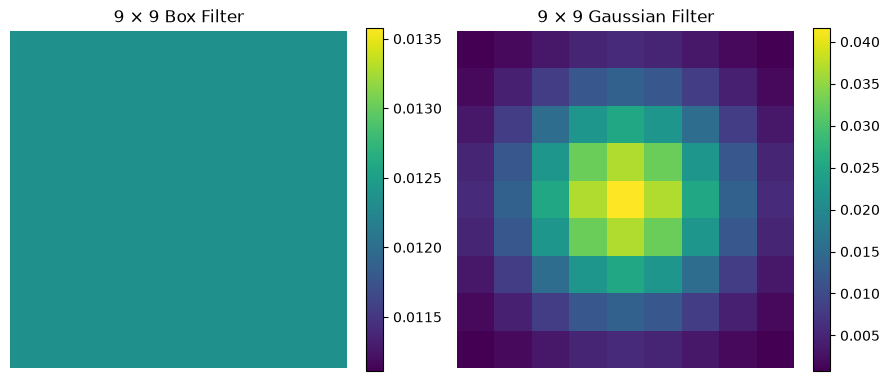

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

box_display = axes[0].imshow(box_filter, cmap="viridis")
axes[0].set_title("9 × 9 Box Filter")
axes[0].axis("off")
fig.colorbar(box_display, ax=axes[0], fraction=0.046)

gaussian_display = axes[1].imshow(
    gaussian_filter,
    cmap="viridis"
)
axes[1].set_title("9 × 9 Gaussian Filter")
axes[1].axis("off")
fig.colorbar(
    gaussian_display,
    ax=axes[1],
    fraction=0.046
)

plt.tight_layout()
plt.show()

The box filter is flat: every location has exactly the same weight.

The Gaussian filter has a peak at its center. Its weights decrease smoothly as the distance from the center increases.

We will now apply each filter to the image exactly once. At every image location, the code selects a local window, multiplies it element by element by the filter, and sums the products.

We use symmetric boundary handling so that the output images have the same dimensions as the original image.

In [30]:
# Both kernels are symmetric, so convolution and correlation
# produce the same results for these particular filters.

box_filtered = convolve2d(
    I,
    box_filter,
    mode="same",
    boundary="symm"
)

gaussian_filtered = convolve2d(
    I,
    gaussian_filter,
    mode="same",
    boundary="symm"
)

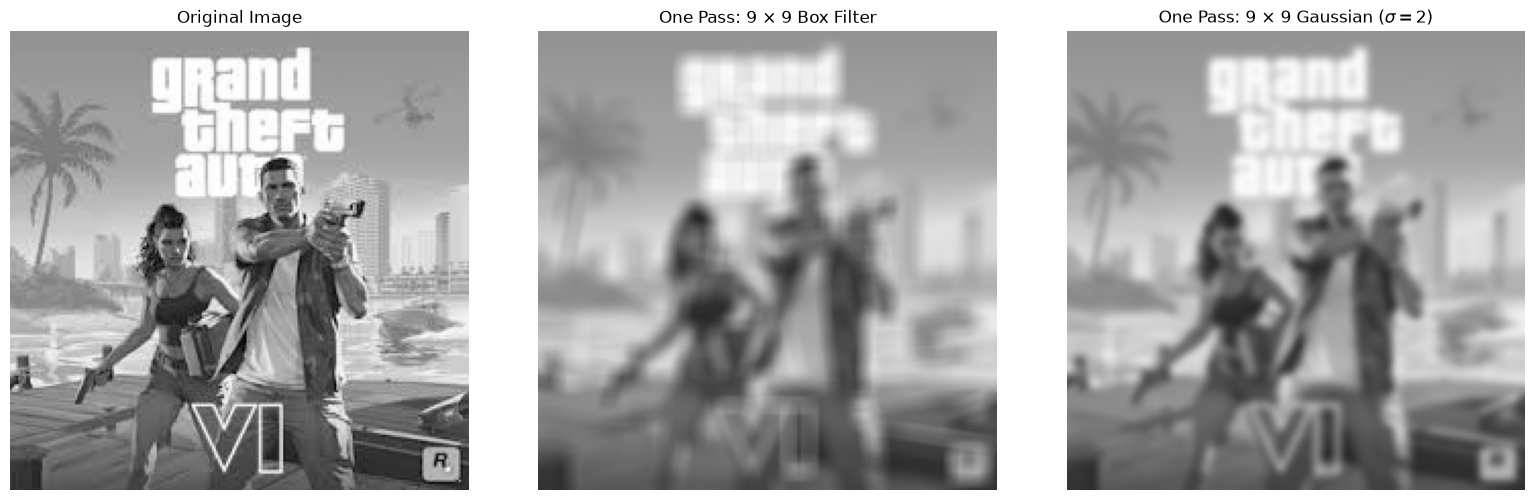

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(I, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(
    box_filtered,
    cmap="gray",
    vmin=0,
    vmax=1
)
axes[1].set_title("One Pass: 9 × 9 Box Filter")
axes[1].axis("off")

axes[2].imshow(
    gaussian_filtered,
    cmap="gray",
    vmin=0,
    vmax=1
)
axes[2].set_title(
    r"One Pass: 9 × 9 Gaussian ($\sigma=2$)"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Comparing the results

Both filters blur the image, but they do so differently.

The box filter treats every pixel inside its window equally. A pixel near the edge of the window has exactly as much influence as the center pixel.

The Gaussian filter places greater emphasis on nearby pixels. Pixels near the boundary of the window contribute less to the result.

Consequently, the Gaussian-filtered image usually appears smoother and more natural, while retaining local structure somewhat better. The box filter can produce a flatter or more uniform-looking blur.

Neither filter knows which image structures are important. Both filters reduce noise by smoothing intensity variations, but they can also blur real details and edges.

## Exercise: What do these filters do?

The four $3\times3$ filters below perform different operations. Before running the code, predict how each filter will change the image.

$$
f_1 =
\begin{bmatrix}
0&0&0\\
0&1&0\\
0&0&0
\end{bmatrix},
\qquad
f_2 =
\begin{bmatrix}
0&0&0\\
0&0&1\\
0&0&0
\end{bmatrix}
$$

$$
f_3 =
\begin{bmatrix}
1&0&-1\\
2&0&-2\\
1&0&-1
\end{bmatrix},
\qquad
f_4 =
\begin{bmatrix}
0&0&0\\
0&2&0\\
0&0&0
\end{bmatrix}
-
\frac{1}{9}
\begin{bmatrix}
1&1&1\\
1&1&1\\
1&1&1
\end{bmatrix}.
$$

For each filter, consider which pixels receive nonzero weights and whether its weights add to 0 or 1.

<details>
<summary><b>Show answers</b></summary>

1. **Identity filter:** returns the original image unchanged.
2. **Translation filter:** copies the pixel immediately to the right, making image features appear shifted one pixel to the left.
3. **Sobel filter:** responds to horizontal intensity changes and therefore detects vertical edges.
4. **Sharpening filter:** computes twice the original image minus a box-blurred image, emphasizing local detail and edges.

</details>

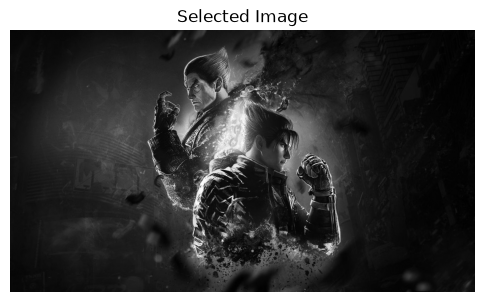

In [34]:
import numpy as np
import matplotlib.pyplot as plt

from io import BytesIO
from urllib.request import Request, urlopen
from PIL import Image
from scipy.signal import correlate2d

# Replace this with any direct image URL.
image_url = (
    "https://static.bandainamcoent.eu/high/tekken/tekken-8/00-page-setup/TEKKEN8_Header_mobile_2.jpg" # <-------------------------------- Change image here
)

request = Request(image_url, headers={"User-Agent": "Mozilla/5.0"})

with urlopen(request) as response:
    image = Image.open(BytesIO(response.read())).convert("L")

I = np.asarray(image, dtype=float) / 255.0

plt.figure(figsize=(6, 4))
plt.imshow(I, cmap="gray", vmin=0, vmax=1)
plt.title("Selected Image")
plt.axis("off")
plt.show()

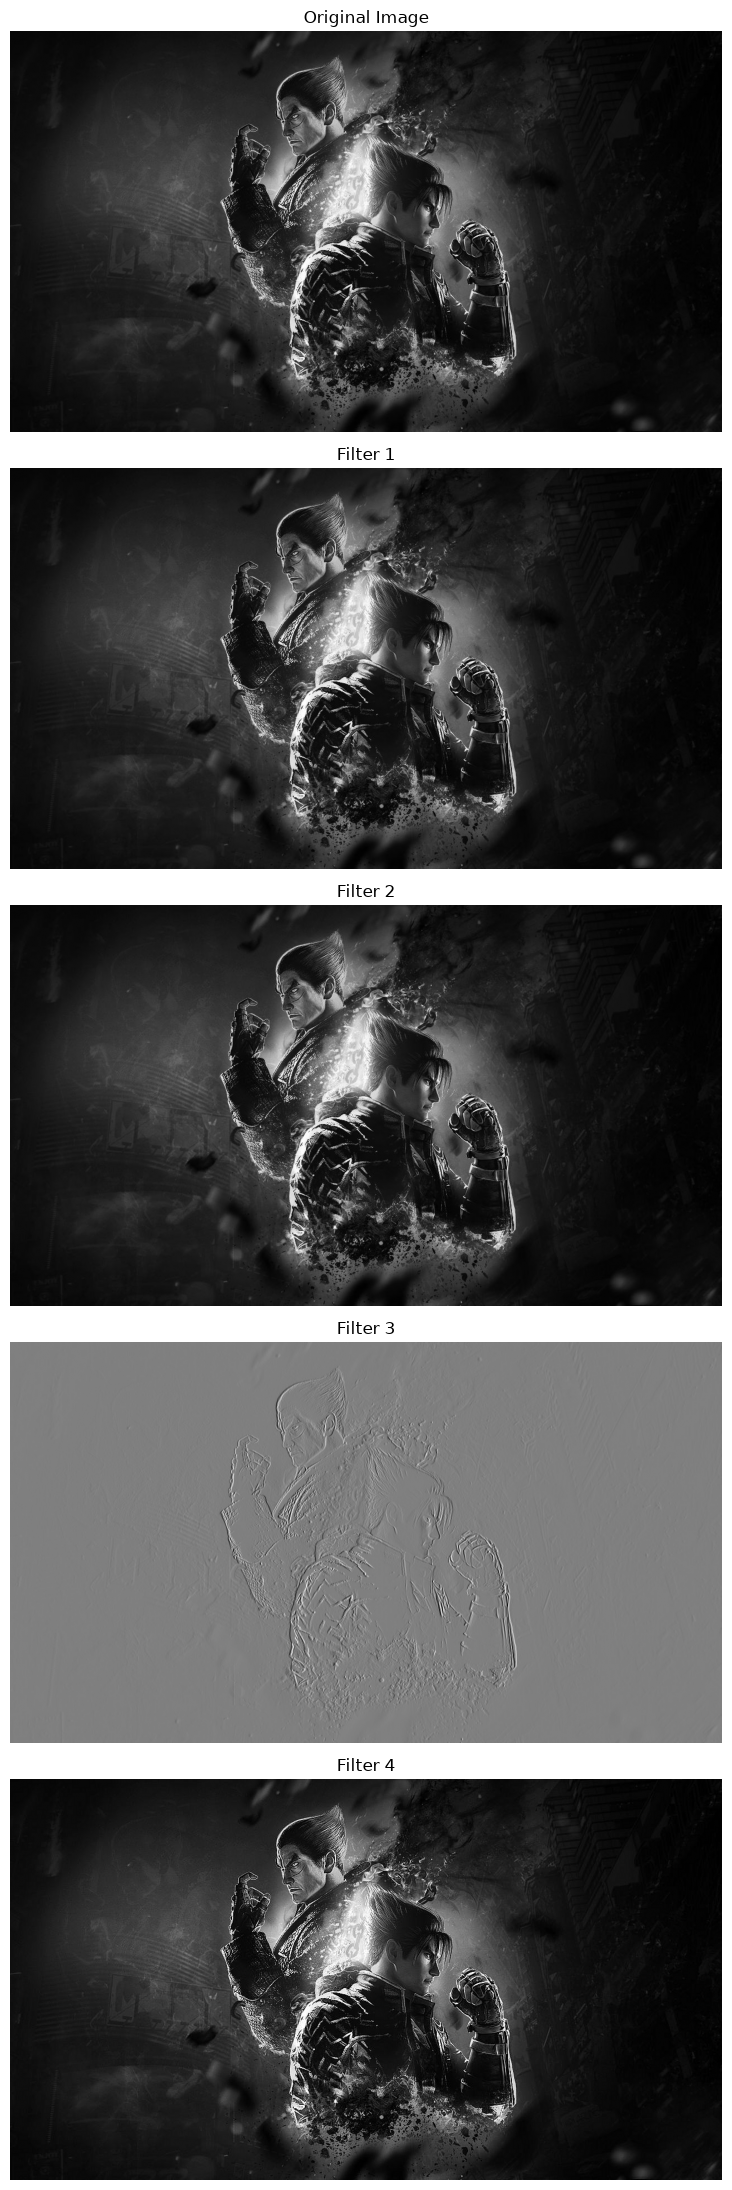

In [36]:
filters = [
    np.array([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]
    ], dtype=float),

    np.array([
        [0, 0, 0],
        [0, 0, 1],
        [0, 0, 0]
    ], dtype=float),

    np.array([
        [1, 0, -1],
        [2, 0, -2],
        [1, 0, -1]
    ], dtype=float),

    np.array([
        [0, 0, 0],
        [0, 2, 0],
        [0, 0, 0]
    ], dtype=float) - np.ones((3, 3)) / 9
]

filtered_images = [
    correlate2d(I, kernel, mode="same", boundary="symm")
    for kernel in filters
]

images = [I] + filtered_images
titles = [
    "Original Image",
    "Filter 1",
    "Filter 2",
    "Filter 3",
    "Filter 4"
]

fig, axes = plt.subplots(5, 1, figsize=(8, 22))

for index, (axis, displayed_image, title) in enumerate(
    zip(axes, images, titles)
):
    if index == 3:
        limit = np.max(np.abs(displayed_image))

        axis.imshow(
            displayed_image,
            cmap="gray",
            vmin=-limit,
            vmax=limit
        )
    else:
        axis.imshow(
            displayed_image,
            cmap="gray",
            vmin=0,
            vmax=1
        )

    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()

## Extending filtering to RGB images

A grayscale image has one intensity value at each location:

$$
I \in \mathbb{R}^{H \times W}.
$$

An RGB image has three values at each location—one red, one green, and one blue:

$$
I \in \mathbb{R}^{H \times W \times 3}.
$$

A spatial filter is usually applied independently to each color channel:

$$
h[m,n,c]
=
\sum_k\sum_l
f[k,l]I[m+k,n+l,c],
$$

where $c$ identifies the red, green, or blue channel. The filter moves spatially across the image but does not mix the color channels.

Near an image boundary, part of the filter window falls outside the image. We must decide what pixel values exist beyond that boundary:

- **Black padding:** assume pixels outside the image are 0.
- **Wrap around:** take missing pixels from the opposite side.
- **Copy edge:** repeat the closest boundary pixel.
- **Reflect:** mirror the image across its boundary.

These choices affect only pixels near the image boundary.

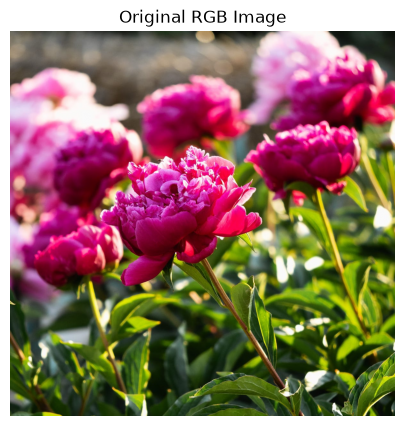

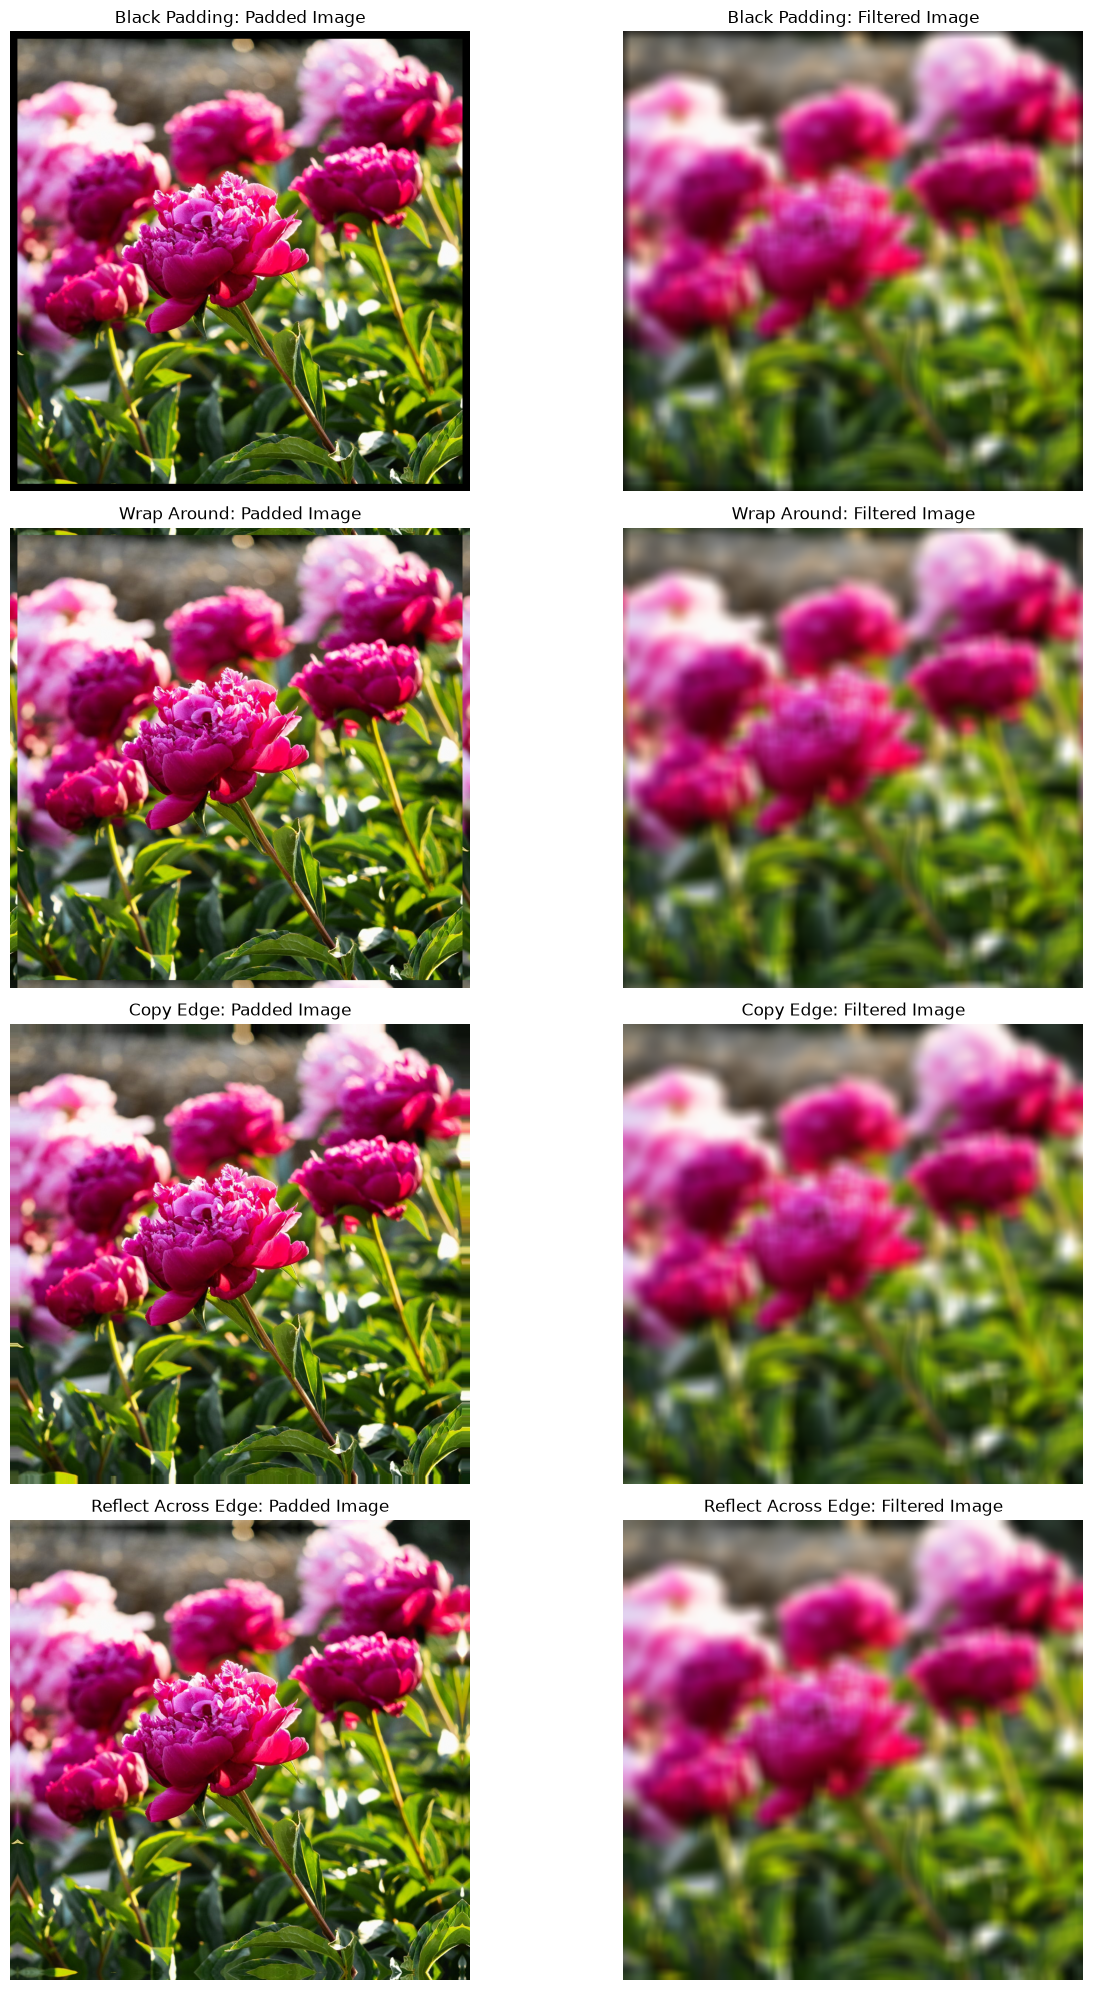

In [48]:
from io import BytesIO
from urllib.request import Request, urlopen
from PIL import Image
from scipy.ndimage import correlate
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter


# Replace this with any direct image URL.
image_url = (
    "https://upload.wikimedia.org/wikipedia/commons/a/a1/Cnidoscolus_stimulosus_%28flower%29_low_res.jpg?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=original" # <-------------------------------- Change image here
)

with urlopen(request) as response:
    rgb_image = Image.open(
        BytesIO(response.read())
    ).convert("RGB")

I_rgb = np.asarray(rgb_image, dtype=float) / 255.0

filter_size = 41
padding_size = filter_size // 2

height, width, channels = I_rgb.shape

# Create the four padded images without loops.
black_padded = np.pad(
    I_rgb,
    (
        (padding_size, padding_size),
        (padding_size, padding_size),
        (0, 0)
    ),
    mode="constant",
    constant_values=0
)

wrap_padded = np.pad(
    I_rgb,
    (
        (padding_size, padding_size),
        (padding_size, padding_size),
        (0, 0)
    ),
    mode="wrap"
)

edge_padded = np.pad(
    I_rgb,
    (
        (padding_size, padding_size),
        (padding_size, padding_size),
        (0, 0)
    ),
    mode="edge"
)

reflect_padded = np.pad(
    I_rgb,
    (
        (padding_size, padding_size),
        (padding_size, padding_size),
        (0, 0)
    ),
    mode="reflect"
)


def filter_padded_image(padded_image):
    """Apply a box filter and crop back to the original size."""

    filtered_padded = uniform_filter(
        padded_image,
        size=(filter_size, filter_size, 1)
    )

    return filtered_padded[
        padding_size:padding_size + height,
        padding_size:padding_size + width,
        :
    ]


# The filtering itself contains no Python loops.
black_filtered = filter_padded_image(black_padded)
wrap_filtered = filter_padded_image(wrap_padded)
edge_filtered = filter_padded_image(edge_padded)
reflect_filtered = filter_padded_image(reflect_padded)

plt.figure(figsize=(8, 5))
plt.imshow(I_rgb)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()


padded_images = [
    black_padded,
    wrap_padded,
    edge_padded,
    reflect_padded
]

filtered_images = [
    black_filtered,
    wrap_filtered,
    edge_filtered,
    reflect_filtered
]

method_names = [
    "Black Padding",
    "Wrap Around",
    "Copy Edge",
    "Reflect Across Edge"
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for row, method_name in enumerate(method_names):
    axes[row, 0].imshow(
        np.clip(padded_images[row], 0, 1)
    )
    axes[row, 0].set_title(
        f"{method_name}: Padded Image"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        np.clip(filtered_images[row], 0, 1)
    )
    axes[row, 1].set_title(
        f"{method_name}: Filtered Image"
    )
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

Consider the image window

$$
W =
\begin{bmatrix}
1&2&3\\
4&5&6\\
7&8&9
\end{bmatrix}
$$

and the filter

$$
f =
\begin{bmatrix}
1&2&3\\
4&5&6\\
7&8&9
\end{bmatrix}.
$$

### Applying the filter using correlation

Correlation uses the filter exactly as written:

$$
W \odot f
=
\begin{bmatrix}
1&2&3\\
4&5&6\\
7&8&9
\end{bmatrix}
\odot
\begin{bmatrix}
1&2&3\\
4&5&6\\
7&8&9
\end{bmatrix}
=
\begin{bmatrix}
1&4&9\\
16&25&36\\
49&64&81
\end{bmatrix}.
$$

Adding the products gives

$$
h_{\text{corr}}
=
1+4+9+16+25+36+49+64+81
=
285.
$$

### Applying the filter using convolution

Convolution first rotates the filter by $180^\circ$.

One way to visualize this is to flip the filter vertically and then horizontally:

$$
\begin{bmatrix}
1&2&3\\
4&5&6\\
7&8&9
\end{bmatrix}
\longrightarrow
\begin{bmatrix}
7&8&9\\
4&5&6\\
1&2&3
\end{bmatrix}
\longrightarrow
\begin{bmatrix}
9&8&7\\
6&5&4\\
3&2&1
\end{bmatrix}.
$$

Therefore,

$$
\operatorname{rot}_{180}(f)
=
\begin{bmatrix}
9&8&7\\
6&5&4\\
3&2&1
\end{bmatrix}.
$$

The rotated filter is then applied to the image window:

$$
W \odot \operatorname{rot}_{180}(f)
=
\begin{bmatrix}
1&2&3\\
4&5&6\\
7&8&9
\end{bmatrix}
\odot
\begin{bmatrix}
9&8&7\\
6&5&4\\
3&2&1
\end{bmatrix}
=
\begin{bmatrix}
9&16&21\\
24&25&24\\
21&16&9
\end{bmatrix}.
$$

Adding the products gives

$$
h_{\text{conv}}
=
9+16+21+24+25+24+21+16+9
=
165.
$$

Thus, correlation and convolution can produce different results when the filter is not rotationally symmetric.